## Decision Tree Algorithm For Binary Classification

## Data Loading & Exploration

In [ ]:
import pandas as pd

In [4]:
df = pd.read_csv(r'data\Heart_Disease_Prediction.csv')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      270 non-null    int64  
 1   Sex                      270 non-null    int64  
 2   Chest pain type          270 non-null    int64  
 3   BP                       270 non-null    int64  
 4   Cholesterol              270 non-null    int64  
 5   FBS over 120             270 non-null    int64  
 6   EKG results              270 non-null    int64  
 7   Max HR                   270 non-null    int64  
 8   Exercise angina          270 non-null    int64  
 9   ST depression            270 non-null    float64
 10  Slope of ST              270 non-null    int64  
 11  Number of vessels fluro  270 non-null    int64  
 12  Thallium                 270 non-null    int64  
 13  Heart Disease            270 non-null    object 
dtypes: float64(1), int64(12), 

In [6]:
df.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


In [7]:
df.describe()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
count,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.00000,270.000000,270.000000,270.000000
mean,54.433333,0.677778,3.174074,131.344444,249.659259,0.148148,1.022222,149.677778,0.329630,1.05000,1.585185,0.670370,4.696296
std,9.109067,0.468195,0.950090,17.861608,51.686237,0.355906,0.997891,23.165717,0.470952,1.14521,0.614390,0.943896,1.940659
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.00000,1.000000,0.000000,3.000000
25%,48.000000,0.000000,3.000000,120.000000,213.000000,0.000000,0.000000,133.000000,0.000000,0.00000,1.000000,0.000000,3.000000
50%,55.000000,1.000000,3.000000,130.000000,245.000000,0.000000,2.000000,153.500000,0.000000,0.80000,2.000000,0.000000,3.000000
75%,61.000000,1.000000,4.000000,140.000000,280.000000,0.000000,2.000000,166.000000,1.000000,1.60000,2.000000,1.000000,7.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.20000,3.000000,3.000000,7.000000


In [8]:
df.isna().sum()

Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
Heart Disease              0
dtype: int64

In [9]:
df.shape

(270, 14)

In [10]:
df.columns

Index(['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120',
       'EKG results', 'Max HR', 'Exercise angina', 'ST depression',
       'Slope of ST', 'Number of vessels fluro', 'Thallium', 'Heart Disease'],
      dtype='object')

In [11]:
df.duplicated().sum()

0

## Data Preprocessing

In [13]:
df['Heart Disease']=df['Heart Disease'].map({
    'Presence' : 1,
    'Absence' : 0
})

In [15]:
X=df.drop('Heart Disease' ,axis=1)
y=df['Heart Disease']

In [16]:
X

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
265,52,1,3,172,199,1,0,162,0,0.5,1,0,7
266,44,1,2,120,263,0,0,173,0,0.0,1,0,7
267,56,0,2,140,294,0,2,153,0,1.3,2,0,3
268,57,1,4,140,192,0,0,148,0,0.4,2,0,6


In [17]:
y

0      1
1      0
2      1
3      0
4      0
      ..
265    0
266    0
267    0
268    0
269    1
Name: Heart Disease, Length: 270, dtype: int64

## Data Visualization

<Axes: xlabel='Heart Disease', ylabel='Cholesterol'>

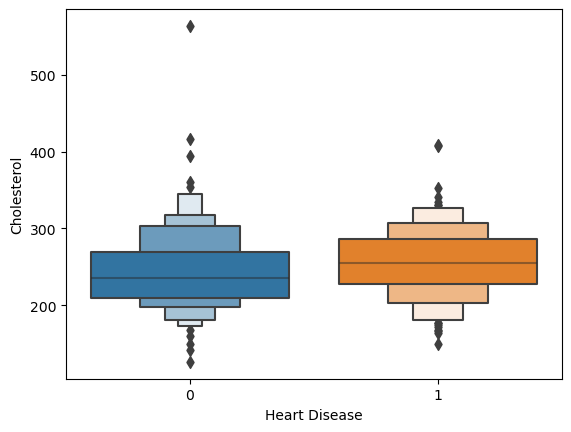

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxenplot(
    x='Heart Disease',
    y='Cholesterol',
    data=df
)

<Axes: >

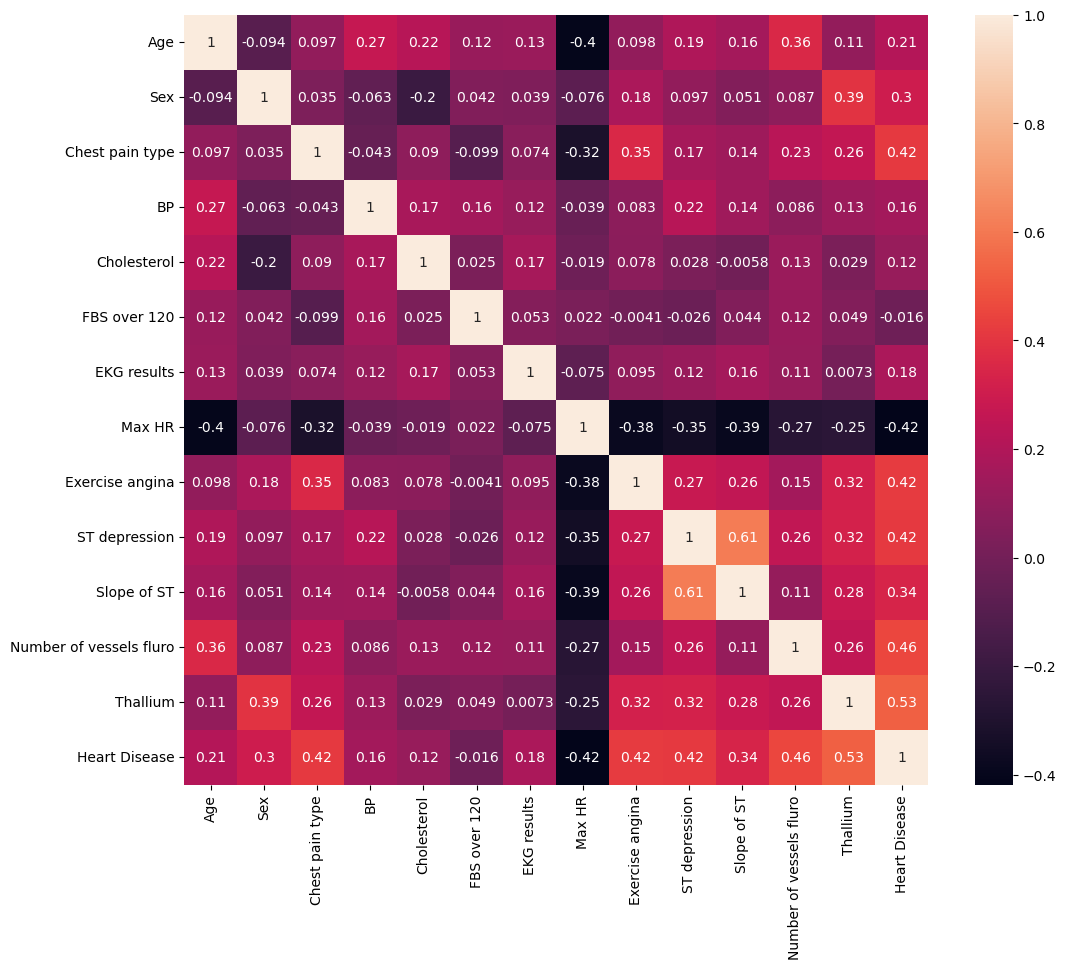

In [129]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(),annot=True)

c:\ProgramData\Anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


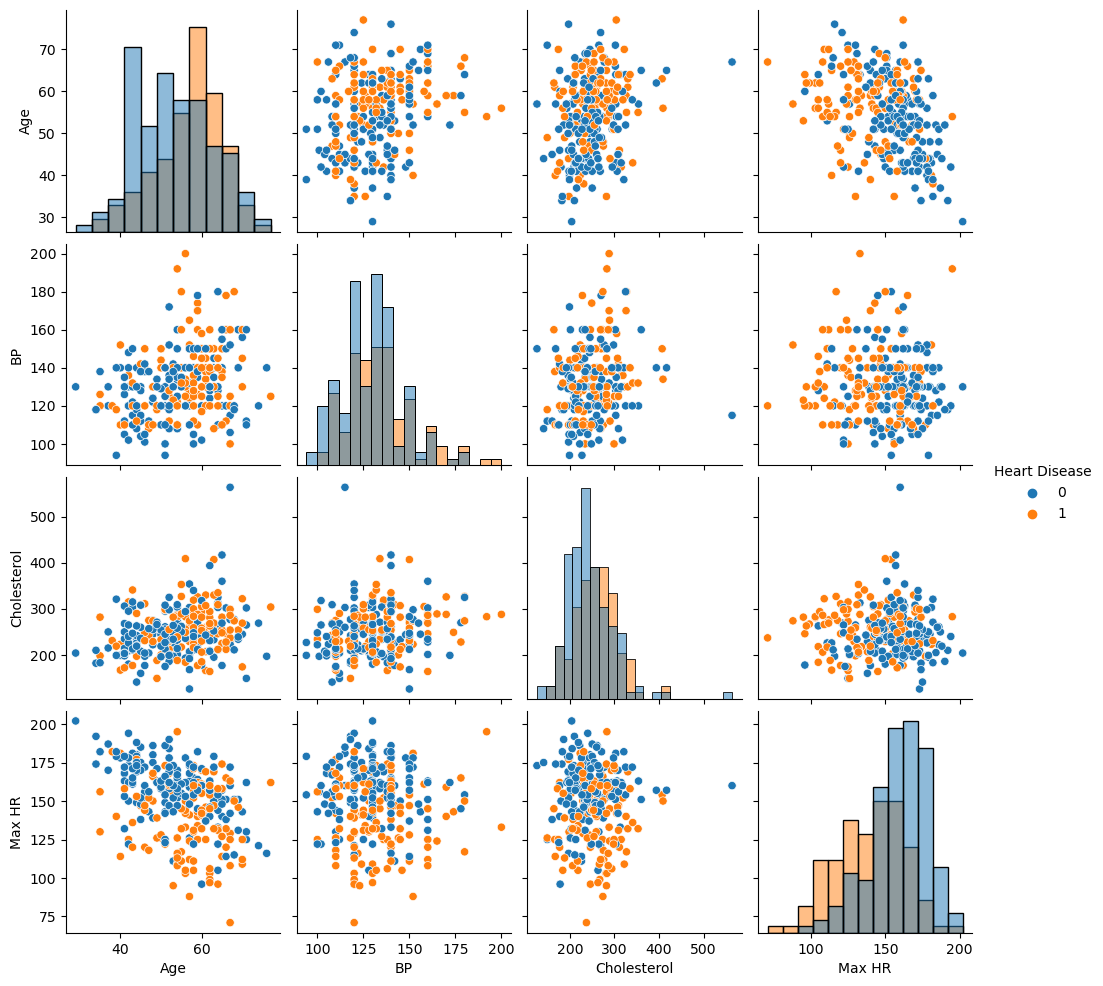

In [130]:
sns.pairplot(
    df[
        [
            'Age',
            'BP',
            'Cholesterol',
            'Max HR',
            'Heart Disease'
        ]
    ],
    hue='Heart Disease',
    diag_kind='hist'
)

## Train/Test Split & Model Training

In [104]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,shuffle=True,random_state=42 ,stratify=y)

In [110]:
from sklearn.tree import DecisionTreeClassifier , plot_tree

model = DecisionTreeClassifier(random_state=42 , max_depth= 4)

In [111]:
model.fit(X_train,y_train)

DecisionTreeClassifier(max_depth=4, random_state=42)

In [112]:
train_accuracy = model.score(X_train,y_train)
test_accuracy = model.score(X_test,y_test)

In [113]:
train_accuracy

0.9166666666666666

In [114]:
test_accuracy

0.7962962962962963

In [115]:
y_pred = model.predict(X_test)
y_pred

array([0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1,
       0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 0, 1, 1, 0, 1], dtype=int64)

## Evaluation

In [116]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [117]:
accuracy=accuracy_score(y_test,y_pred)
precision=precision_score(y_test,y_pred)
recall=recall_score(y_test,y_pred)
f1score=f1_score(y_test,y_pred)
classificationreport = classification_report(y_test,y_pred)

In [118]:
accuracy

0.7962962962962963

In [119]:
precision

0.7407407407407407

In [120]:
recall

0.8333333333333334

In [121]:
f1score

0.7843137254901961

In [122]:
classificationreport

'              precision    recall  f1-score   support\n\n           0       0.85      0.77      0.81        30\n           1       0.74      0.83      0.78        24\n\n    accuracy                           0.80        54\n   macro avg       0.80      0.80      0.80        54\nweighted avg       0.80      0.80      0.80        54\n'

In [123]:
results=pd.DataFrame({
    'Actual Heart Disease ' : y_test.values,
    'Predicted Heart Disease' : y_pred
})

results.head(10)

,Actual Heart Disease,Predicted Heart Disease
0,0,0
1,0,0
2,0,0
3,1,1
4,0,0
5,0,0
6,0,0
7,1,1
8,1,1
9,1,1


## Confusion Matrix

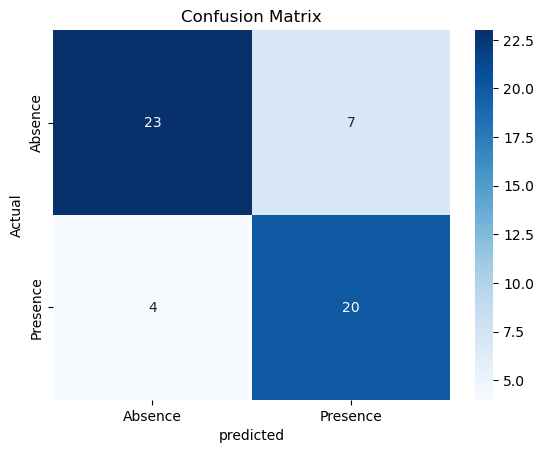

In [140]:
cm = confusion_matrix(y_test,y_pred)
sns.heatmap(
    cm,
    annot= True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Absence','Presence'],
    yticklabels=['Absence','Presence']
)
plt.xlabel('predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## Tree Visualization

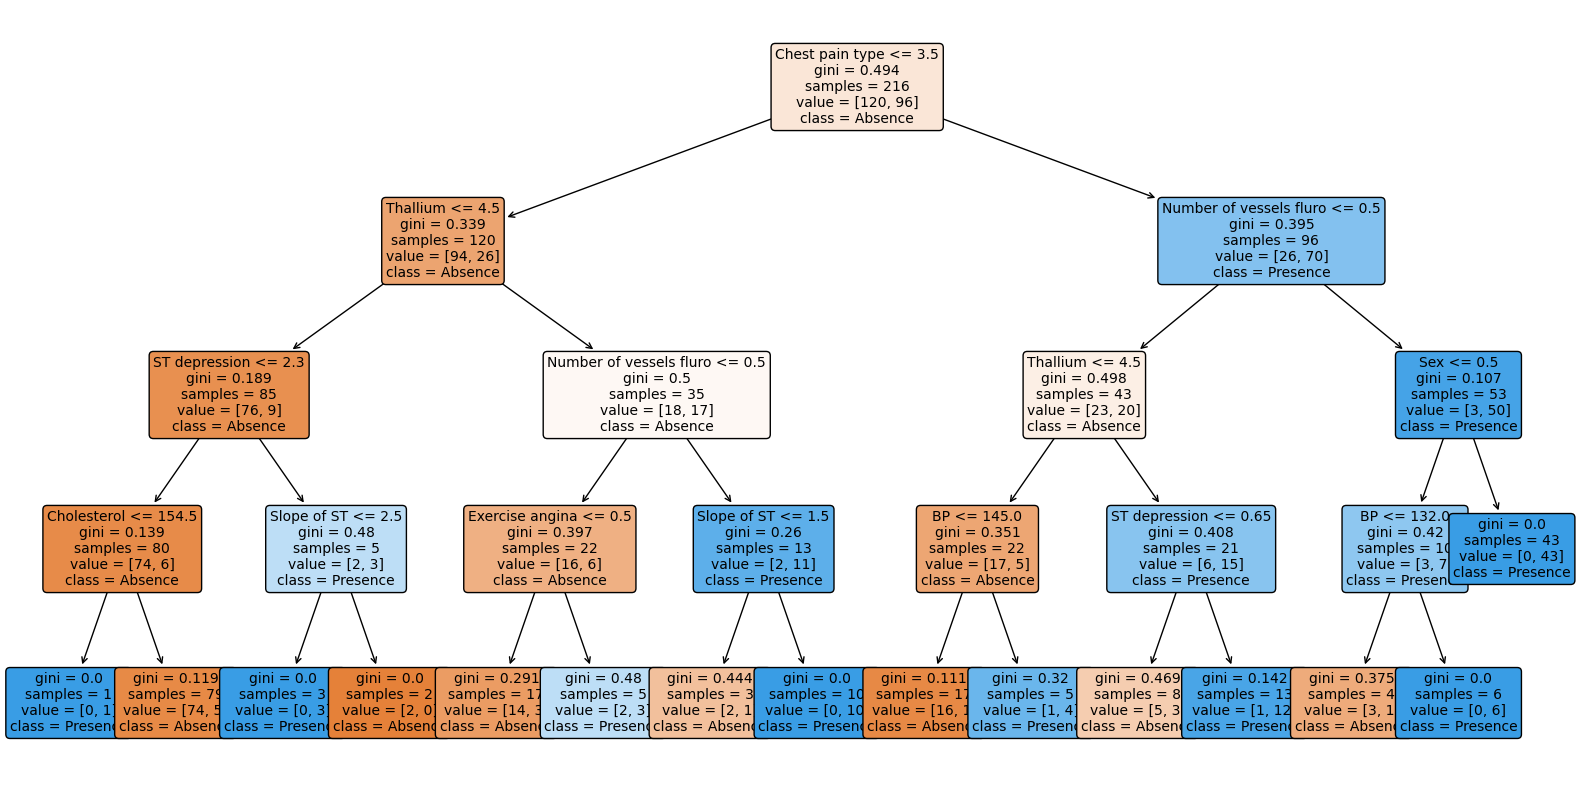

In [131]:
plt.figure(figsize=(20,10))
plot_tree(
    model,
    feature_names=list(X.columns),
    class_names=['Absence', 'Presence'],
    filled=True,
    fontsize=10,
    rounded=True
)
plt.show()

## Feature Importance

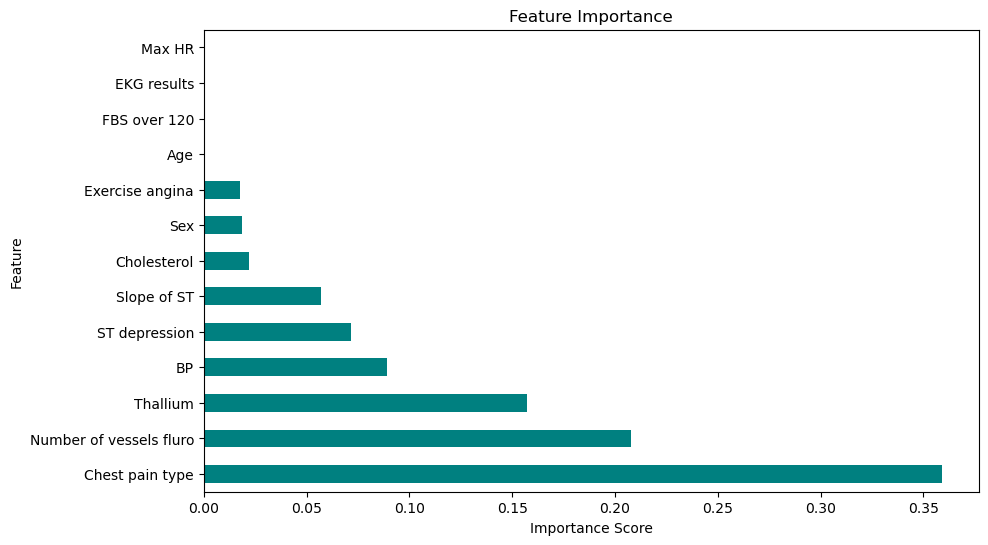

In [141]:
importance = pd.Series(model.feature_importances_,index=X.columns)
importance = importance.sort_values(ascending=False)

plt.figure(figsize=(10,6))
importance.plot(kind='barh' , color ='teal')
plt.title('Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()